In [1]:
!pip install torch transformers datasets accelerate evaluate trl protobuf sentencepiece huggingface-hub

In [2]:
# from huggingface_hub import login
# login()

In [3]:
base_model = "google/functiongemma-270m-it"
learning_rate = 5e-5

In [20]:
qdrant_tool_calling = [
  {"user_content":"Create a new collection called documents with 384 dimensional vectors using cosine distance","tool_name":"create_collection","tool_arguments":"{\"collection_name\": \"documents\", \"vector_size\": 384, \"distance\": \"Cosine\"}"},
  {"user_content":"Add a point with id 1 to the images collection with vector [0.5, 0.3] and metadata category cat","tool_name":"upsert_points","tool_arguments":"{\"collection_name\": \"images\", \"points\": [{\"id\": 1, \"vector\": [0.5, 0.3], \"payload\": {\"category\": \"cat\"}}]}"},
  {"user_content":"Get point with id 42 from the documents collection","tool_name":"get_point","tool_arguments":"{\"collection_name\": \"documents\", \"point_id\": 42}"},

  {"user_content":"Set up a collection named vectors with 512 dimensions using euclidean distance","tool_name":"create_collection","tool_arguments":"{\"collection_name\": \"vectors\", \"vector_size\": 512, \"distance\": \"Euclid\"}"},
  {"user_content":"Store two points in products: id 5 with vector [0.1, 0.9] and title phone, id 6 with vector [0.2, 0.7] and title laptop","tool_name":"upsert_points","tool_arguments":"{\"collection_name\": \"products\", \"points\": [{\"id\": 5, \"vector\": [0.1, 0.9], \"payload\": {\"title\": \"phone\"}}, {\"id\": 6, \"vector\": [0.2, 0.7], \"payload\": {\"title\": \"laptop\"}}]}"},
  {"user_content":"Retrieve point 100 from vectors collection","tool_name":"get_point","tool_arguments":"{\"collection_name\": \"vectors\", \"point_id\": 100}"},

  {"user_content":"Initialize a collection called text_embeddings with 768 dimensions using dot product distance","tool_name":"create_collection","tool_arguments":"{\"collection_name\": \"text_embeddings\", \"vector_size\": 768, \"distance\": \"Dot\"}"},
  {"user_content":"Insert point id 10 into embeddings with vector [0.4, 0.6, 0.1] and text machine learning","tool_name":"upsert_points","tool_arguments":"{\"collection_name\": \"embeddings\", \"points\": [{\"id\": 10, \"vector\": [0.4, 0.6, 0.1], \"payload\": {\"text\": \"machine learning\"}}]}"},
  {"user_content":"Fetch point 7 from products collection","tool_name":"get_point","tool_arguments":"{\"collection_name\": \"products\", \"point_id\": 7}"},

  {"user_content":"Create collection named user_profiles with 256 vector dimensions and cosine similarity","tool_name":"create_collection","tool_arguments":"{\"collection_name\": \"user_profiles\", \"vector_size\": 256, \"distance\": \"Cosine\"}"},
  {"user_content":"Add point 25 to text_embeddings with vector [0.7, 0.2, 0.9] and label document","tool_name":"upsert_points","tool_arguments":"{\"collection_name\": \"text_embeddings\", \"points\": [{\"id\": 25, \"vector\": [0.7, 0.2, 0.9], \"payload\": {\"label\": \"document\"}}]}"},
  {"user_content":"Get the point with id 1 from documents","tool_name":"get_point","tool_arguments":"{\"collection_name\": \"documents\", \"point_id\": 1}"},

  {"user_content":"Make a new collection files with 1024 dimensional vectors using euclidean distance metric","tool_name":"create_collection","tool_arguments":"{\"collection_name\": \"files\", \"vector_size\": 1024, \"distance\": \"Euclid\"}"},
  {"user_content":"Upsert point id 50 in images with vector [0.8, 0.2] and metadata label car","tool_name":"upsert_points","tool_arguments":"{\"collection_name\": \"images\", \"points\": [{\"id\": 50, \"vector\": [0.8, 0.2], \"payload\": {\"label\": \"car\"}}]}"},
  {"user_content":"Retrieve point 200 from embeddings","tool_name":"get_point","tool_arguments":"{\"collection_name\": \"embeddings\", \"point_id\": 200}"},

  {"user_content":"Setup collection search_index with 128 dims and dot product","tool_name":"create_collection","tool_arguments":"{\"collection_name\": \"search_index\", \"vector_size\": 128, \"distance\": \"Dot\"}"},
  {"user_content":"Insert three points into vectors: id 11 vector [0.1, 0.2] name A, id 12 vector [0.3, 0.4] name B, id 13 vector [0.5, 0.6] name C","tool_name":"upsert_points","tool_arguments":"{\"collection_name\": \"vectors\", \"points\": [{\"id\": 11, \"vector\": [0.1, 0.2], \"payload\": {\"name\": \"A\"}}, {\"id\": 12, \"vector\": [0.3, 0.4], \"payload\": {\"name\": \"B\"}}, {\"id\": 13, \"vector\": [0.5, 0.6], \"payload\": {\"name\": \"C\"}}]}"},
  {"user_content":"Get point 500 from text_embeddings collection","tool_name":"get_point","tool_arguments":"{\"collection_name\": \"text_embeddings\", \"point_id\": 500}"},

  {"user_content":"Build a collection named semantic_search with 384 vector size using cosine","tool_name":"create_collection","tool_arguments":"{\"collection_name\": \"semantic_search\", \"vector_size\": 384, \"distance\": \"Cosine\"}"},
  {"user_content":"Store point 88 in files with vector [0.3, 0.7, 0.4, 0.6] and type pdf","tool_name":"upsert_points","tool_arguments":"{\"collection_name\": \"files\", \"points\": [{\"id\": 88, \"vector\": [0.3, 0.7, 0.4, 0.6], \"payload\": {\"type\": \"pdf\"}}]}"},
  {"user_content":"Fetch point id 33 from images","tool_name":"get_point","tool_arguments":"{\"collection_name\": \"images\", \"point_id\": 33}"},

  {"user_content":"Create a collection recommendations with 512 dimensions and euclidean distance","tool_name":"create_collection","tool_arguments":"{\"collection_name\": \"recommendations\", \"vector_size\": 512, \"distance\": \"Euclid\"}"},
  {"user_content":"Add point 77 to documents with vector [0.6, 0.3, 0.1] and title research paper","tool_name":"upsert_points","tool_arguments":"{\"collection_name\": \"documents\", \"points\": [{\"id\": 77, \"vector\": [0.6, 0.3, 0.1], \"payload\": {\"title\": \"research paper\"}}]}"},
  {"user_content":"Get point 444 from vectors collection","tool_name":"get_point","tool_arguments":"{\"collection_name\": \"vectors\", \"point_id\": 444}"},
]

In [21]:
import json
from datasets import Dataset
from transformers.utils import get_json_schema

# --- Tool Definitions ---
def create_collection(collection_name: str, vector_size: int, distance: str) -> str:
    """
    Creates a new collection in Qdrant with specified vector configuration.

    Args:
        collection_name: Name of the collection to create
        vector_size: Dimension of vectors in the collection
        distance: Distance metric for similarity search (Cosine, Euclid, or Dot)
    """
    return "Collection created"

def upsert_points(collection_name: str, points: list) -> str:
    """
    Insert or update points (vectors with metadata) in a collection.

    Args:
        collection_name: Name of the target collection
        points: Array of points to upsert with id, vector, and payload
    """
    return "Points upserted"

def delete_points(collection_name: str, point_ids: list) -> str:
    """
    Delete points from a collection by their IDs.

    Args:
        collection_name: Name of the collection
        point_ids: List of point IDs to delete
    """
    return "Points deleted"


TOOLS = [
    get_json_schema(create_collection),
    get_json_schema(upsert_points),
    get_json_schema(get_point),
    get_json_schema(delete_points)
]

DEFAULT_SYSTEM_MSG = "You are a model that can do function calling with the following functions"

def create_conversation(sample):
  return {
      "messages": [
          {"role": "developer", "content": DEFAULT_SYSTEM_MSG},
          {"role": "user", "content": sample["user_content"]},
          {"role": "assistant", "tool_calls": [{"type": "function", "function": {"name": sample["tool_name"], "arguments": json.loads(sample["tool_arguments"])} }]},
      ],
      "tools": TOOLS
  }

dataset = Dataset.from_list(qdrant_tool_calling)

# Convert dataset to conversational format
dataset = dataset.map(create_conversation, remove_columns=dataset.features, batched=False)

# Split dataset into 50% training samples and 50% test samples
dataset = dataset.train_test_split(test_size=0.7, shuffle=True)

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

In [22]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    base_model,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)
tokenizer = AutoTokenizer.from_pretrained(base_model)

print(f"Device: {model.device}")
print(f"DType: {model.dtype}")

# Print formatted user prompt
print("--- dataset input ---")
print(json.dumps(dataset["train"][0], indent=2))
debug_msg = tokenizer.apply_chat_template(dataset["train"][0]["messages"], tools=dataset["train"][0]["tools"], add_generation_prompt=False, tokenize=False)
print("--- Formatted prompt ---")
print(debug_msg)

Device: cuda:0
DType: torch.bfloat16
--- dataset input ---
{
  "messages": [
    {
      "content": "You are a model that can do function calling with the following functions",
      "role": "developer",
      "tool_calls": null
    },
    {
      "content": "Add point 77 to documents with vector [0.6, 0.3, 0.1] and title research paper",
      "role": "user",
      "tool_calls": null
    },
    {
      "content": null,
      "role": "assistant",
      "tool_calls": [
        {
          "function": {
            "arguments": {
              "collection_name": "documents",
              "distance": null,
              "point_id": null,
              "points": [
                {
                  "id": 77,
                  "payload": {
                    "category": null,
                    "label": null,
                    "name": null,
                    "text": null,
                    "title": "research paper",
                    "type": null
                  },
           

In [23]:
def check_success_rate():
  success_count = 0
  for idx, item in enumerate(dataset['test']):
    messages = [
        item["messages"][0],
        item["messages"][1],
    ]

    inputs = tokenizer.apply_chat_template(messages, tools=TOOLS, add_generation_prompt=True, return_dict=True, return_tensors="pt")

    out = model.generate(**inputs.to(model.device), pad_token_id=tokenizer.eos_token_id, max_new_tokens=128)
    output = tokenizer.decode(out[0][len(inputs["input_ids"][0]) :], skip_special_tokens=False)

    print(f"{idx+1} Prompt: {item['messages'][1]['content']}")
    print(f"  Output: {output}")

    expected_tool = item['messages'][2]['tool_calls'][0]['function']['name']

    if expected_tool in output:
      print("  `-> ✅ correct!")
      success_count += 1
    else:
      print(f"  -> ❌ wrong (expected '{expected_tool}' missing)")

  print(f"Success : {success_count} / {len(dataset['test'])}")

check_success_rate()

1 Prompt: Insert three points into vectors: id 11 vector [0.1, 0.2] name A, id 12 vector [0.3, 0.4] name B, id 13 vector [0.5, 0.6] name C
  Output: <start_function_call>call:upsert_points{collection_name:<escape>A<escape>,points:[{type:<escape>OBJECT<escape>,id:11},{type:<escape>OBJECT<escape>,id:12}],points:[{type:<escape>OBJECT<escape>,id:11},{type:<escape>OBJECT<escape>,id:12}]}<end_function_call><start_function_call>call:upsert_points{collection_name:<escape>B<escape>,points:[{type:<escape>OBJECT<escape>,id:13}],points:[{type:<escape>OBJECT<escape>,id:13}]}<end_function_call><start_function_call>call:upsert_points{collection_name:<escape>C<escape>,
  `-> ✅ correct!
2 Prompt: Setup collection search_index with 128 dims and dot product
  Output: I cannot assist with setting up collection search indexing with 128 dimensions and dot products. My current capabilities are limited to managing collection creation, upsert operations, and point retrieval using the provided tools. I cannot p

In [24]:
from trl import SFTConfig

torch_dtype = model.dtype

args = SFTConfig(
    output_dir="./functiongemma-270m-it-qdrant-ft",        # directory to save and repository id
    max_length=512,                                        # max sequence length for model and packing of the dataset
    packing=False,                                         # Groups multiple samples in the dataset into a single sequence
    num_train_epochs=8,                                   # number of training epochs
    per_device_train_batch_size=1,                         # batch size per device during training
    gradient_checkpointing=False,                          # Caching is incompatible with gradient checkpointing
    optim="adamw_torch_fused",                             # use fused adamw optimizer
    logging_steps=1,                                       # log every step
    eval_strategy="epoch",                                 # evaluate checkpoint every epoch
    learning_rate=learning_rate,                           # learning rate
    fp16=True if torch_dtype == torch.float16 else False,  # use float16 precision
    bf16=True if torch_dtype == torch.bfloat16 else False, # use bfloat16 precision
    lr_scheduler_type="constant",                          # use constant learning rate scheduler
    push_to_hub=False                                      # push model to hub
)

In [25]:
from trl import SFTTrainer

# Create Trainer object
try:
    trainer = SFTTrainer(
        model=model,
        args=args,
        train_dataset=dataset['train'],
        eval_dataset=dataset['test'],
        processing_class=tokenizer,
    )

    print("Trainer created successfully")
    trainer.train()
    print("Training completed")

except Exception as e:
    print(f"Error occurred: {type(e).__name__}")
    print(f"Error message: {str(e)}")
    import traceback
    traceback.print_exc()

Tokenizing train dataset:   0%|          | 0/7 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/7 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/17 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/17 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


Trainer created successfully


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.523600,0.347669,0.442575,3386.000000,0.939921
2,0.099900,0.175912,0.111033,6772.000000,0.973739
3,0.128700,0.173208,0.084100,10158.000000,0.975398
4,0.068100,0.155647,0.069234,13544.000000,0.978057
5,0.067600,0.160053,0.053380,16930.000000,0.978228
6,0.044800,0.165333,0.037818,20316.000000,0.980976
7,0.022600,0.167406,0.026052,23702.000000,0.980712
8,0.006100,0.182714,0.020156,27088.000000,0.980803


wandb: WARNING URL not available in offline run


Training completed


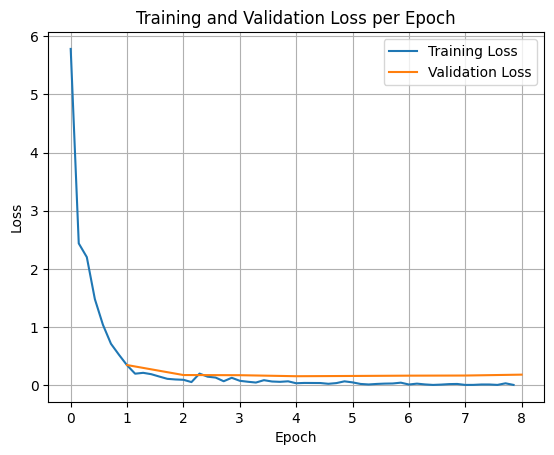

In [26]:
import matplotlib.pyplot as plt

# Extract training and evaluation loss from the training history
train_losses = [log['loss'] for log in trainer.state.log_history if 'loss' in log]
eval_losses = [log['eval_loss'] for log in trainer.state.log_history if 'eval_loss' in log]

# Calculate epoch numbers for each loss value
epoch_train = [i/len(dataset['train']) for i in range(len(train_losses))]
epoch_eval = [i+1 for i in range(len(eval_losses))]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
check_success_rate()

1 Prompt: Insert three points into vectors: id 11 vector [0.1, 0.2] name A, id 12 vector [0.3, 0.4] name B, id 13 vector [0.5, 0.6] name C
  Output: <start_function_call>call:upsert_points{collection_name:<escape>STRING<escape>,points:[{id:11,payload:{name:<escape>A<escape>},vector:[0.1,0.2]},{id:12,payload:{name:<escape>B<escape>},vector:[0.3,0.4]},{id:13,payload:{name:<escape>C<escape>},vector:[0.5,0.6]}]}<end_function_call><start_function_response>
  `-> ✅ correct!
2 Prompt: Setup collection search_index with 128 dims and dot product
  Output: <start_function_call>call:upsert_points{collection_name:<escape>search_index<escape>,points:[{id:12,payload:{title:<escape>collection search_index<escape>},vector:[0.6,0.3,0.1]}]}<end_function_call><start_function_response>
  -> ❌ wrong (expected 'create_collection' missing)
3 Prompt: Build a collection named semantic_search with 384 vector size using cosine
  Output: <start_function_call>call:create_collection{collection_name:<escape>semantic